## Exploratory Data Analysis: Credit Card Default Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

df = pd.read_csv(r"credit_card_default.csv")
df.head()

,Unnamed: 0,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,...,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
0,0,20000,Female,University,Married,24.0,Payment delayed 2 months,Payment delayed 2 months,Payed duly,Payed duly,...,0,0,0,0,689,0,0,0,0,1
1,1,120000,Female,University,Single,26.0,Payed duly,Payment delayed 2 months,Unknown,Unknown,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,2,90000,Female,University,Single,34.0,Unknown,Unknown,Unknown,Unknown,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,3,50000,Female,University,Married,37.0,Unknown,Unknown,Unknown,Unknown,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,4,50000,Male,University,Married,57.0,Payed duly,Unknown,Payed duly,Unknown,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df = df.drop(columns=["Unnamed: 0"])
df.columns

Index(['limit_bal', 'sex', 'education', 'marriage', 'age',
       'payment_status_sep', 'payment_status_aug', 'payment_status_jul',
       'payment_status_jun', 'payment_status_may', 'payment_status_apr',
       'bill_statement_sep', 'bill_statement_aug', 'bill_statement_jul',
       'bill_statement_jun', 'bill_statement_may', 'bill_statement_apr',
       'previous_payment_sep', 'previous_payment_aug', 'previous_payment_jul',
       'previous_payment_jun', 'previous_payment_may', 'previous_payment_apr',
       'default_payment_next_month'],
      dtype='object')

In [5]:
df.shape

(30000, 24)

In [6]:
df.describe()

,limit_bal,age,bill_statement_sep,bill_statement_aug,bill_statement_jul,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
count,30000.000000,29850.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.490117,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,9.217852,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   limit_bal                   30000 non-null  int64  
 1   sex                         29850 non-null  object 
 2   education                   29850 non-null  object 
 3   marriage                    29850 non-null  object 
 4   age                         29850 non-null  float64
 5   payment_status_sep          30000 non-null  object 
 6   payment_status_aug          30000 non-null  object 
 7   payment_status_jul          30000 non-null  object 
 8   payment_status_jun          30000 non-null  object 
 9   payment_status_may          30000 non-null  object 
 10  payment_status_apr          30000 non-null  object 
 11  bill_statement_sep          30000 non-null  int64  
 12  bill_statement_aug          30000 non-null  int64  
 13  bill_statement_jul          300

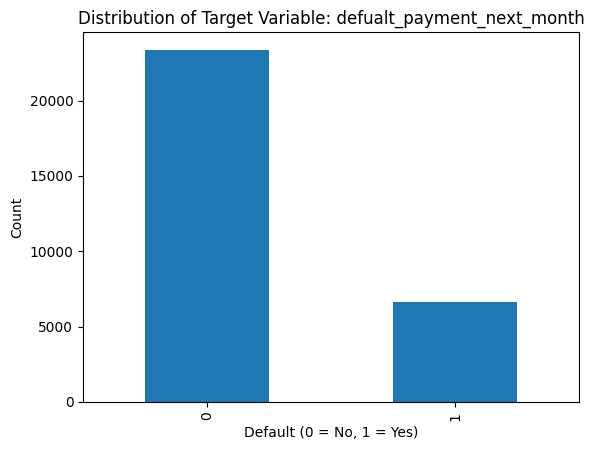

In [10]:
#target variable
df["default_payment_next_month"].value_counts().plot(kind="bar")

plt.title("Distribution of Target Variable: defualt_payment_next_month")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

In [11]:
counts = df["default_payment_next_month"].value_counts()

print("No Default (0):", counts[0])
print("Default (1):", counts[1])

No Default (0): 23364
Default (1): 6636


array([[<Axes: title={'center': 'limit_bal'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'bill_statement_sep'}>,
        <Axes: title={'center': 'bill_statement_aug'}>],
       [<Axes: title={'center': 'bill_statement_jul'}>,
        <Axes: title={'center': 'bill_statement_jun'}>,
        <Axes: title={'center': 'bill_statement_may'}>,
        <Axes: title={'center': 'bill_statement_apr'}>],
       [<Axes: title={'center': 'previous_payment_sep'}>,
        <Axes: title={'center': 'previous_payment_aug'}>,
        <Axes: title={'center': 'previous_payment_jul'}>,
        <Axes: title={'center': 'previous_payment_jun'}>],
       [<Axes: title={'center': 'previous_payment_may'}>,
        <Axes: title={'center': 'previous_payment_apr'}>,
        <Axes: title={'center': 'default_payment_next_month'}>, <Axes: >]],
      dtype=object)

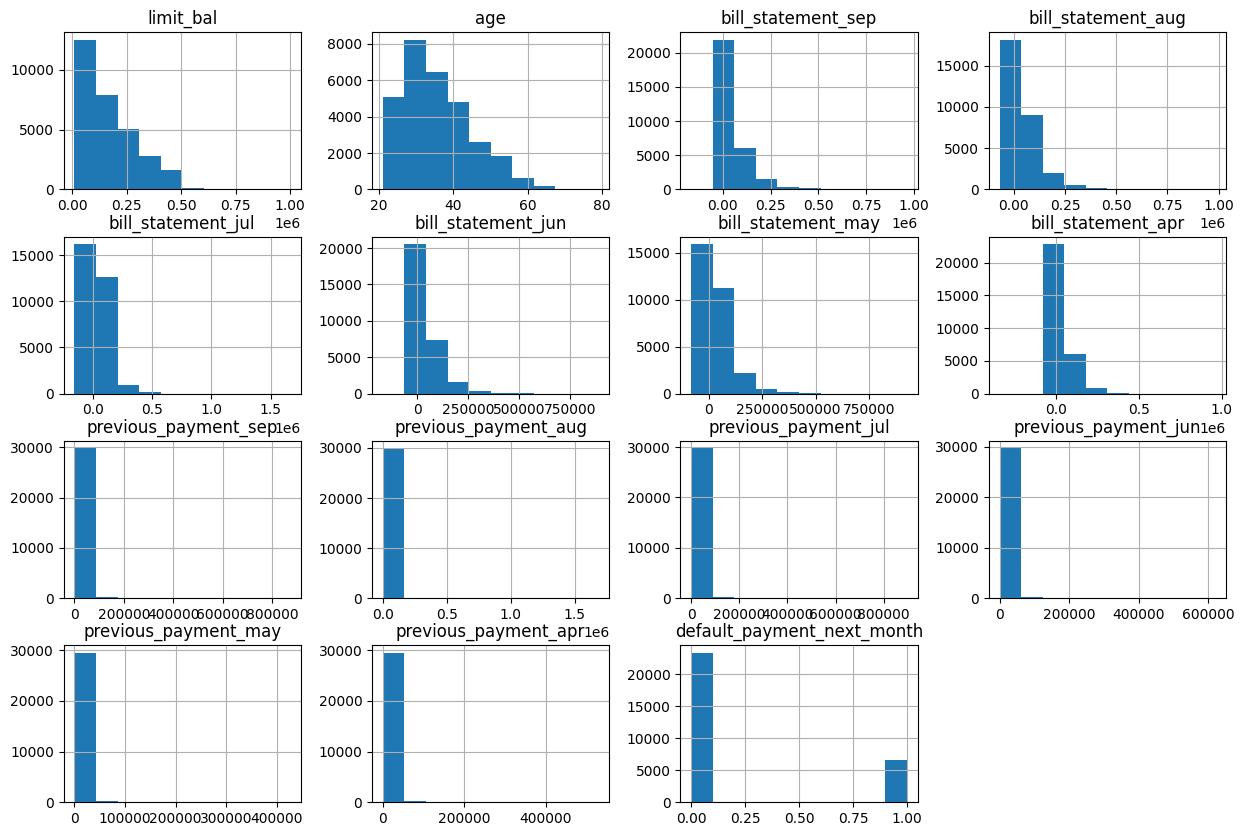

In [13]:
#histograms of all numerical features to see distributions
df.hist(figsize=(15,10))

In [14]:
#define numerical and categorical columns
numeric_features = [col for col in df.columns if df[col].dtype != 'O']
categorical_features = [col for col in df.columns if df[col].dtype == 'O']

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numerical features: ['limit_bal', 'age', 'bill_statement_sep', 'bill_statement_aug', 'bill_statement_jul', 'bill_statement_jun', 'bill_statement_may', 'bill_statement_apr', 'previous_payment_sep', 'previous_payment_aug', 'previous_payment_jul', 'previous_payment_jun', 'previous_payment_may', 'previous_payment_apr', 'default_payment_next_month']

Categorical features: ['sex', 'education', 'marriage', 'payment_status_sep', 'payment_status_aug', 'payment_status_jul', 'payment_status_jun', 'payment_status_may', 'payment_status_apr']


In [15]:
#proportion of each category
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True) * 100)
    print("-----------------------------")


sex
sex
Female    60.39196
Male      39.60804
Name: proportion, dtype: float64
-----------------------------

education
education
University         46.767169
Graduate school    35.299832
High school        16.368509
Others              1.564489
Name: proportion, dtype: float64
-----------------------------

marriage
marriage
Single     53.236181
Married    45.510888
Others      1.252931
Name: proportion, dtype: float64
-----------------------------

payment_status_sep
payment_status_sep
Unknown                     58.320000
Payed duly                  18.953333
Payment delayed 1 month     12.293333
Payment delayed 2 months     8.890000
Payment delayed 3 months     1.073333
Payment delayed 4 months     0.253333
Payment delayed 5 months     0.086667
Payment delayed 8 months     0.063333
Payment delayed 6 months     0.036667
Payment delayed 7 months     0.030000
Name: proportion, dtype: float64
-----------------------------

payment_status_aug
payment_status_aug
Unknown                 

Categorical feature analysis reveals that gender, education, and marital status are relatively balanced, suggesting they may have limited predictive power individually. However, payment status variables across multiple months reveal strong patterns. A large propportion of customers fall under the "Unknown" category, followed by those who paid duly and those with delayed payments. Since payment history reflects financial behavior, these feautres are likely to be predictive of defualt risk. Customers with delayed payments are expected to have a higher likelihood of default compared to those who consistently pay on time. 

In [16]:
#Do people with delayed payments defualt more?
pd.crosstab(df["payment_status_sep"], df["default_payment_next_month"], normalize="index")

default_payment_next_month,0,1
payment_status_sep,,
Payed duly,0.832219,0.167781
Payment delayed 1 month,0.660521,0.339479
Payment delayed 2 months,0.308586,0.691414
Payment delayed 3 months,0.242236,0.757764
Payment delayed 4 months,0.315789,0.684211
Payment delayed 5 months,0.500000,0.500000
Payment delayed 6 months,0.454545,0.545455
Payment delayed 7 months,0.222222,0.777778
Payment delayed 8 months,0.421053,0.578947


The analysis of payment status shows a clear relationship between delayed payments and default risk. Customers who paid on time or fall under the "Unknown" category have relatively low defualt rates (approximately 13-17%). As payment delays increase, the probability of defualt rises significantly. For example, customers with a 2-month delay have a defualt rate of approximately 69%, while those with a 3-month delay exceeed 75%. This shows that payment history is a predictive feature and plays a role in determining default risk. 

In [17]:
#repeat for different month
pd.crosstab(df["payment_status_aug"], df["default_payment_next_month"], normalize="index")

default_payment_next_month,0,1
payment_status_aug,,
Payed duly,0.840331,0.159669
Payment delayed 1 month,0.821429,0.178571
Payment delayed 2 months,0.443850,0.556150
Payment delayed 3 months,0.383436,0.616564
Payment delayed 4 months,0.494949,0.505051
Payment delayed 5 months,0.400000,0.600000
Payment delayed 6 months,0.250000,0.750000
Payment delayed 7 months,0.400000,0.600000
Payment delayed 8 months,1.000000,0.000000


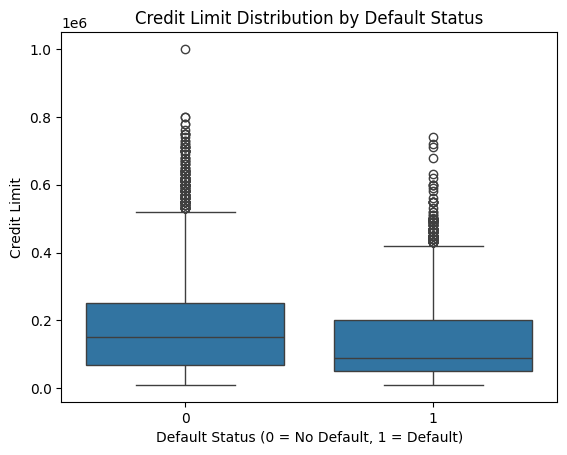

In [20]:
#check financial patterns (numerical features vs target) 
sns.boxplot(x="default_payment_next_month", y="limit_bal", data=df)

plt.title("Credit Limit Distribution by Default Status")
plt.xlabel("Default Status (0 = No Default, 1 = Default)")
plt.ylabel("Credit Limit")

plt.show()

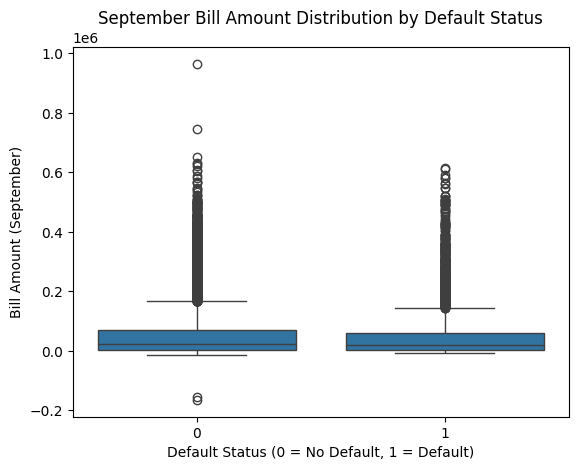

In [21]:
sns.boxplot(x="default_payment_next_month", y="bill_statement_sep", data=df)

plt.title("September Bill Amount Distribution by Default Status")
plt.xlabel("Default Status (0 = No Default, 1 = Default)")
plt.ylabel("Bill Amount (September)")

plt.show()

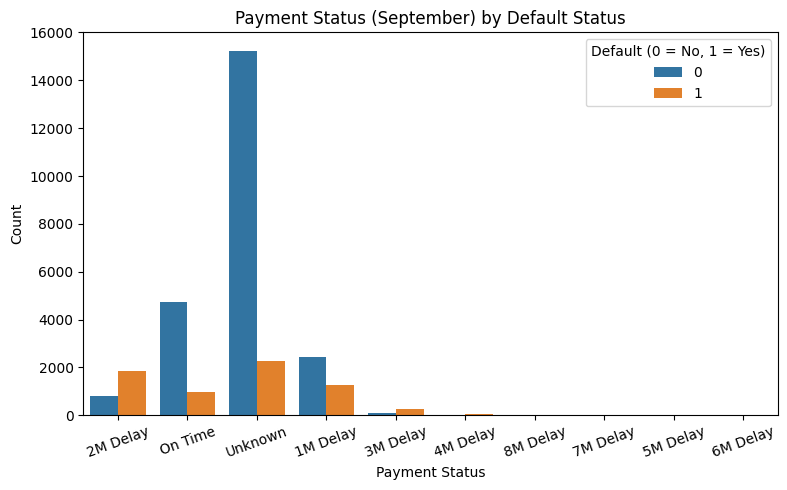

In [26]:
#count plot of categorical features by target class 

label_map = {
    "Payed duly": "On Time",
    "Payment delayed 1 month": "1M Delay",
    "Payment delayed 2 months": "2M Delay",
    "Payment delayed 3 months": "3M Delay",
    "Payment delayed 4 months": "4M Delay",
    "Payment delayed 5 months": "5M Delay",
    "Payment delayed 6 months": "6M Delay",
    "Payment delayed 7 months": "7M Delay",
    "Payment delayed 8 months": "8M Delay",
    "Unknown": "Unknown"
}

#apply mapping 
df["payment_status_sep_clean"] = df["payment_status_sep"].map(label_map)

plt.figure(figsize=(8,5))

sns.countplot(x="payment_status_sep_clean", 
              hue="default_payment_next_month", 
              data=df)

plt.title("Payment Status (September) by Default Status")
plt.xlabel("Payment Status")
plt.ylabel("Count")

plt.xticks(rotation=20)
plt.legend(title="Default (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

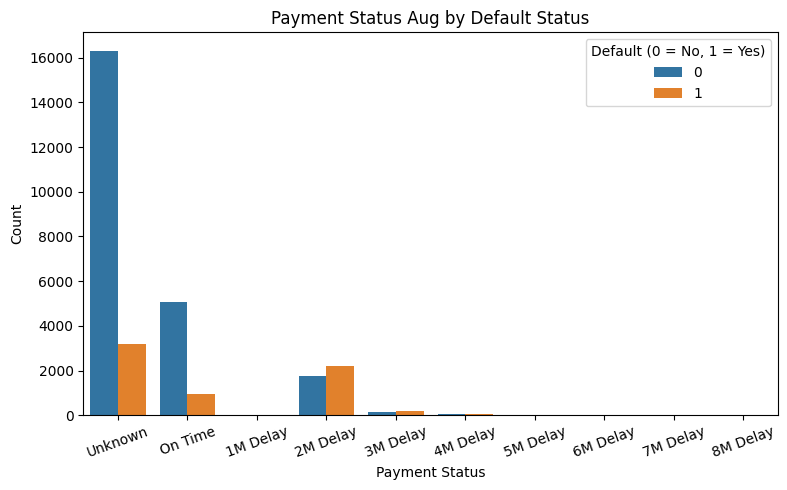

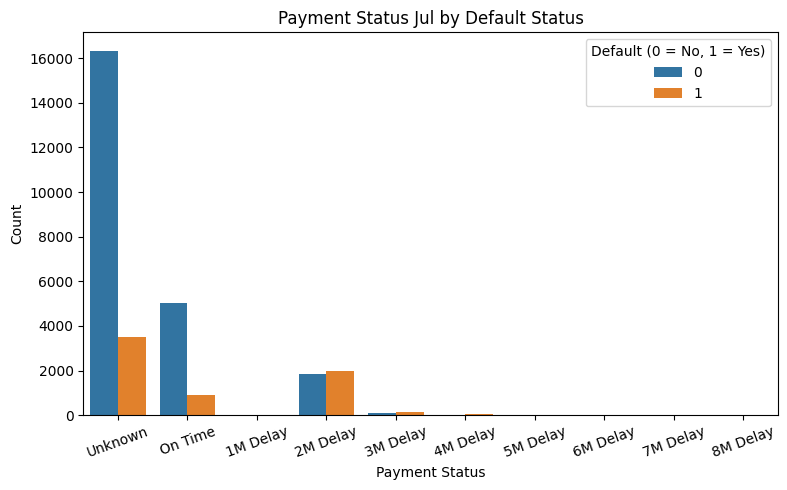

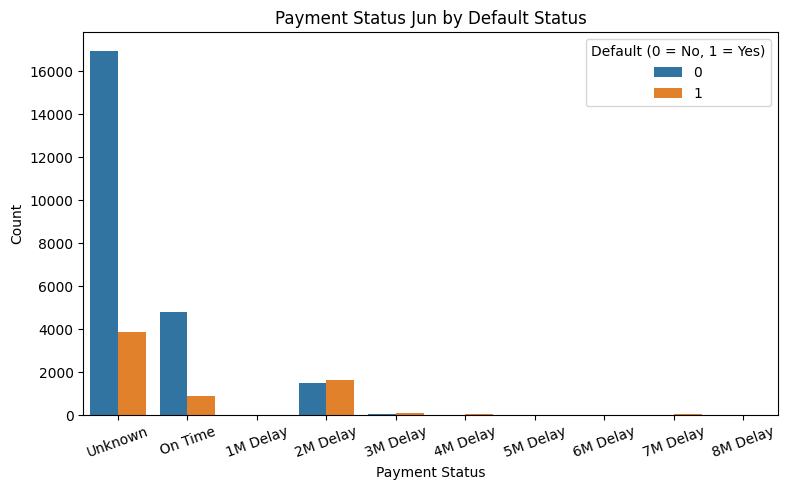

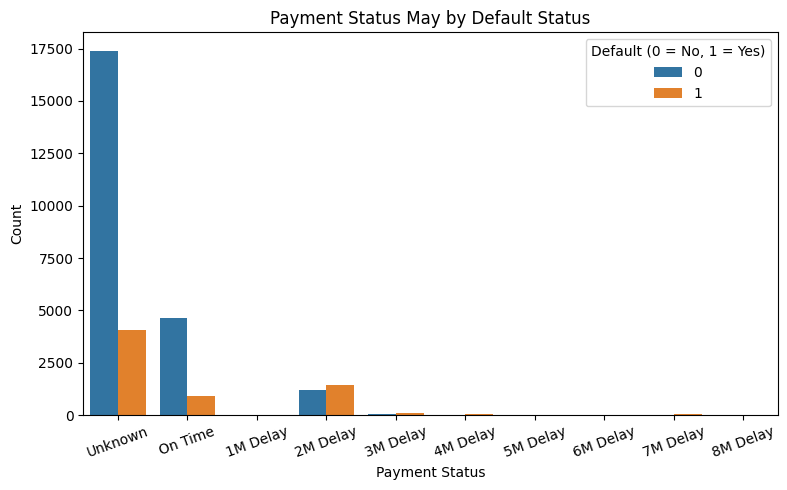

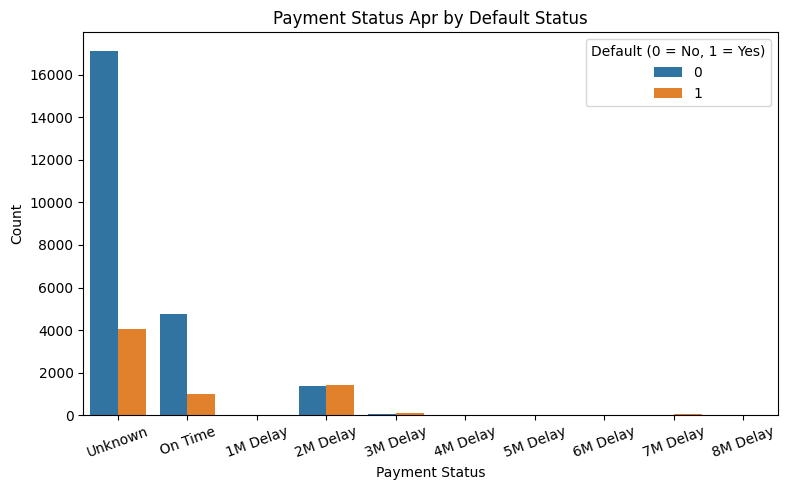

In [27]:
payment_cols = [
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr"
]

#shorten labels
label_map = {
    "Payed duly": "On Time",
    "Payment delayed 1 month": "1M Delay",
    "Payment delayed 2 months": "2M Delay",
    "Payment delayed 3 months": "3M Delay",
    "Payment delayed 4 months": "4M Delay",
    "Payment delayed 5 months": "5M Delay",
    "Payment delayed 6 months": "6M Delay",
    "Payment delayed 7 months": "7M Delay",
    "Payment delayed 8 months": "8M Delay",
    "Unknown": "Unknown"
}

#order category
order = [
    "Unknown", "On Time", "1M Delay", "2M Delay", "3M Delay",
    "4M Delay", "5M Delay", "6M Delay", "7M Delay", "8M Delay"
]

#loop through each payment status column and create a count plot
for col in payment_cols:
    #create temporary cleaned labels for readability in the plot
    temp_col = f"{col}_clean"
    df[temp_col] = df[col].map(label_map)

    plt.figure(figsize=(8,5))
    sns.countplot(
        x=temp_col,
        hue="default_payment_next_month",
        data=df,
        order=order
    )

    plt.title(f"{col.replace('_', ' ').title()} by Default Status")
    plt.xlabel("Payment Status")
    plt.ylabel("Count")

    plt.xticks(rotation=20)
    plt.legend(title="Default (0 = No, 1 = Yes)")

    plt.tight_layout()
    plt.show()

The count plots of payment status across multiple months show a consistent pattern in customer behavior. Most customers fall into the "Unknown" or "On Time" categories, and these groups are predominantly associated with non-defualt cases. As payment delays increase, the proportion of defaulters rises noticeably. Customers with delays of two or more months show a much higher likelihood of default compared to those who pay on time. This trend is consistent across all months, reinforcing that payment history is a strong predictor of default risk. 

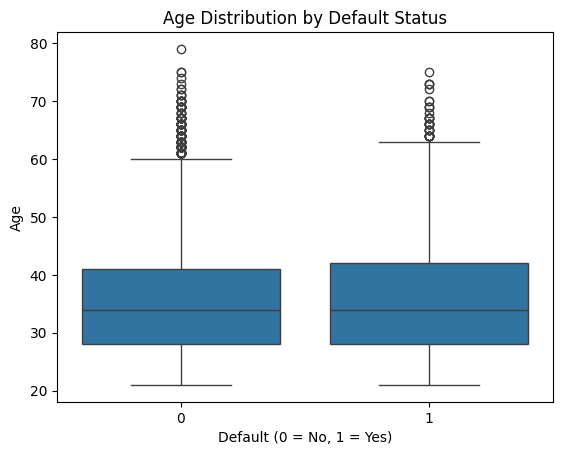

In [28]:
#age vs default 
sns.boxplot(x="default_payment_next_month", y="age", data=df)

plt.title("Age Distribution by Default Status")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

Distributions overlap, most people fall between 28-42 years in both groups. 

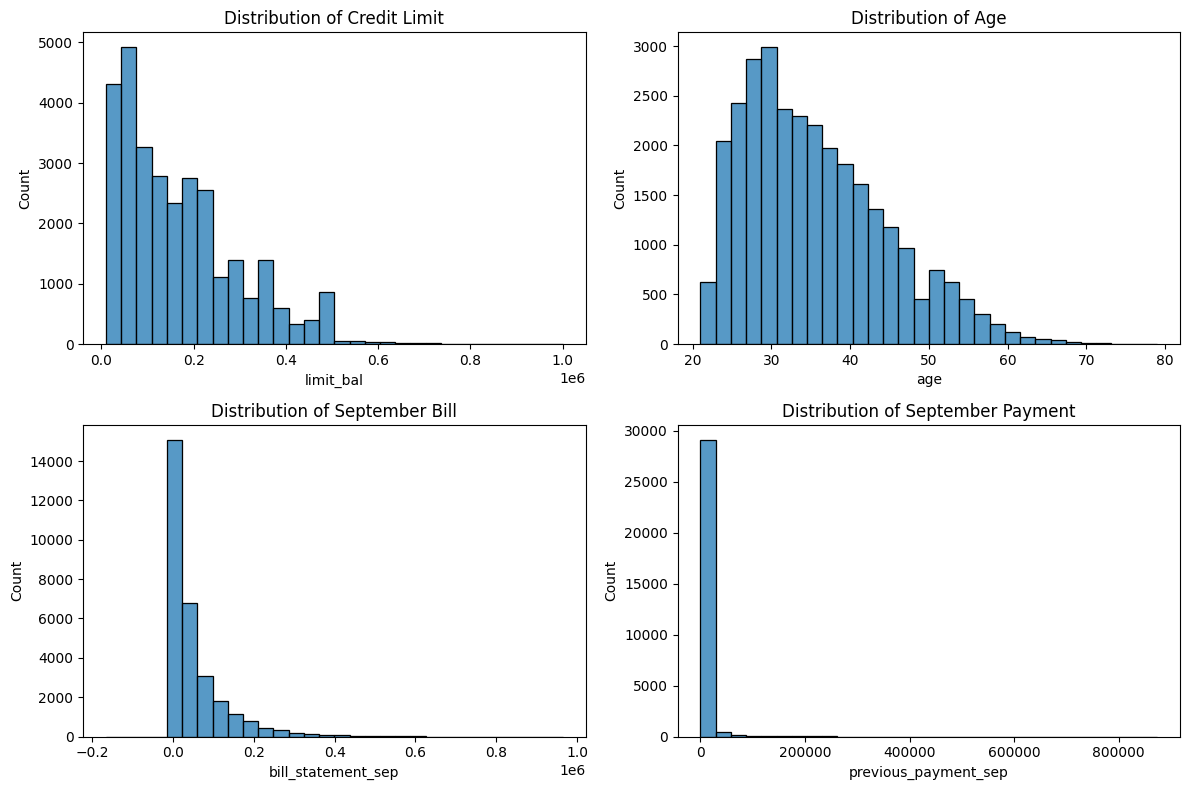

In [29]:
#limit balance and age distributions
fig, axes = plt.subplots(2, 2, figsize=(12,8))

#plot 1: credit limit
sns.histplot(df["limit_bal"], bins=30, ax=axes[0,0])
axes[0,0].set_title("Distribution of Credit Limit")

#plot 2: age
sns.histplot(df["age"], bins=30, ax=axes[0,1])
axes[0,1].set_title("Distribution of Age")

#plot 3: bill
sns.histplot(df["bill_statement_sep"], bins=30, ax=axes[1,0])
axes[1,0].set_title("Distribution of September Bill")

#plot 4: payment 
sns.histplot(df["previous_payment_sep"], bins=30, ax=axes[1,1])
axes[1,1].set_title("Distribution of September Payment")

plt.tight_layout()
plt.show()

The distribution plots show that financial variables such as credit limit, bill amounts, and payments amounts are right-skewed, with most observations concentrated at lower values and a small number of extreme high values. This indicates the presence of outliers and significant variablility in customer financial behavior. In contrast, age follows a more normal distribution, with most customers falling between 25 and 45 years old. These findings suggest that finanacial variables may require scaling or transformation during preprocessing, while age is less likely to require adjustment. 

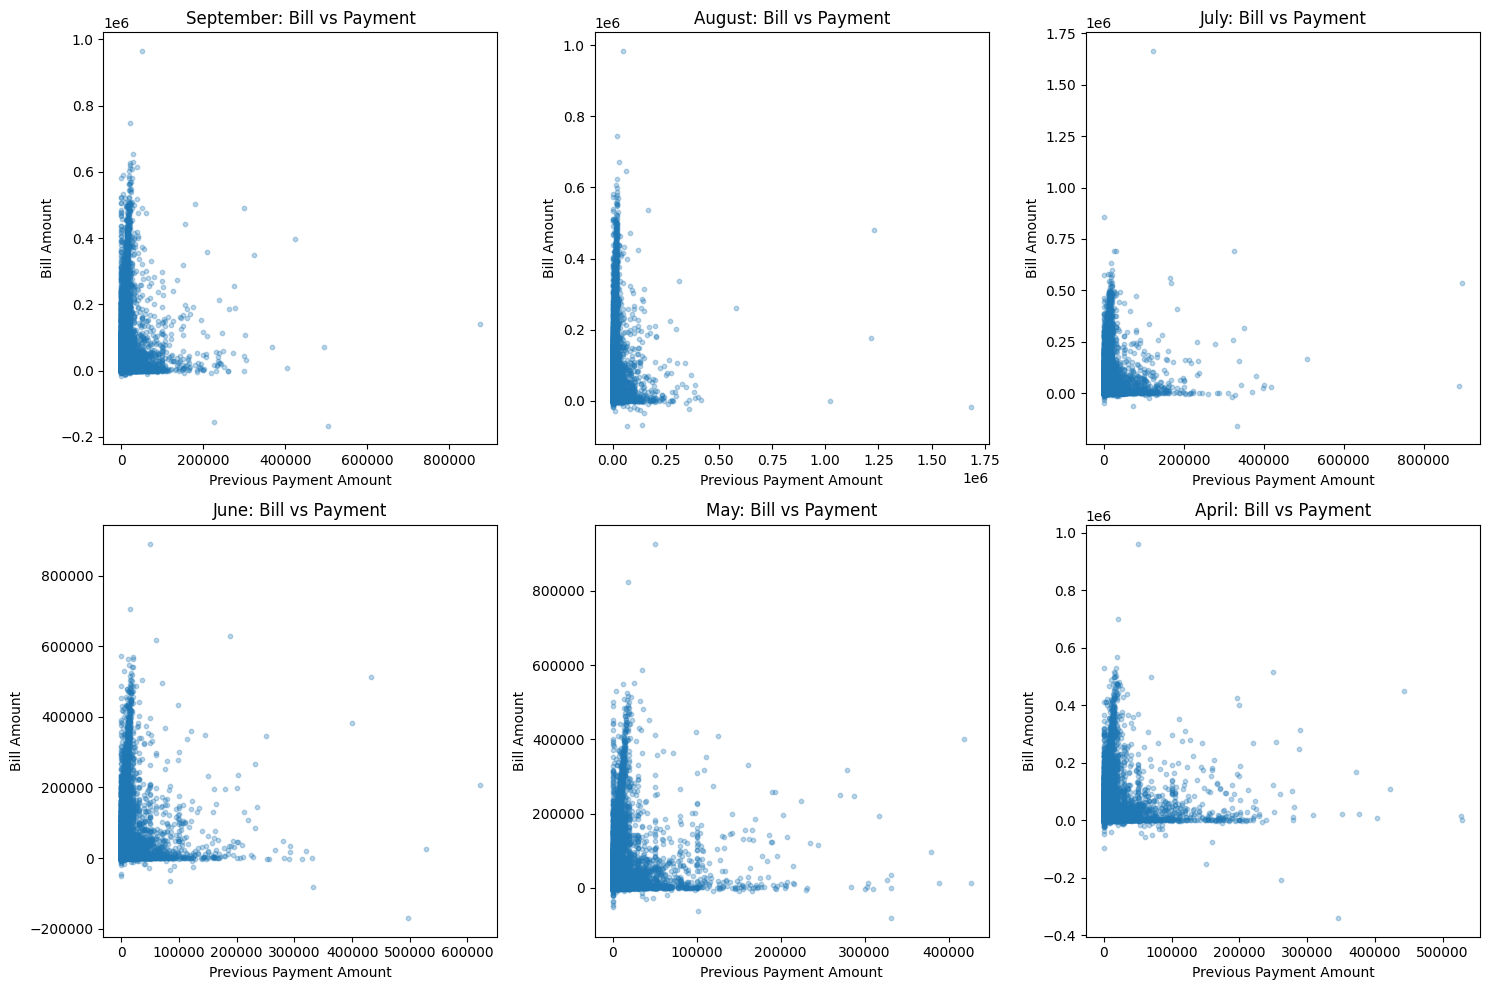

In [30]:
#scatter plots of bill amount and previous payment month by month
#helps identify whether customers tend to make low payments relative to their bill amounts and whether extreme values or patterns exist

month_pairs = [
    ("previous_payment_sep", "bill_statement_sep", "September"),
    ("previous_payment_aug", "bill_statement_aug", "August"),
    ("previous_payment_jul", "bill_statement_jul", "July"),
    ("previous_payment_jun", "bill_statement_jun", "June"),
    ("previous_payment_may", "bill_statement_may", "May"),
    ("previous_payment_apr", "bill_statement_apr", "April")
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (pay_col, bill_col, month) in enumerate(month_pairs):
    axes[i].scatter(
        df[pay_col],
        df[bill_col],
        alpha=0.3,
        s=10
    )
    axes[i].set_title(f"{month}: Bill vs Payment")
    axes[i].set_xlabel("Previous Payment Amount")
    axes[i].set_ylabel("Bill Amount")

plt.tight_layout()
plt.show()

The scatter plots comparing monthly bill amoutns and corresponding payment amounts reveal a consistent pattern across all six months. Most observations are concentrated near low payment values, while bill amounts exhibit a wide range, indicating that many customers make relatively small payments regardless of their outstanding balance. The relationship between bill amounts and payments appears weak, as higher bills do not consistently correspond to higher payments. Additionally, the presence of outliers and negative bill values suggest variablility in repayment behavior and occasional overpayments. Overall, these findings highlight that payment behavior, rather than bill size alone, is a key factor in understanding default risk. 

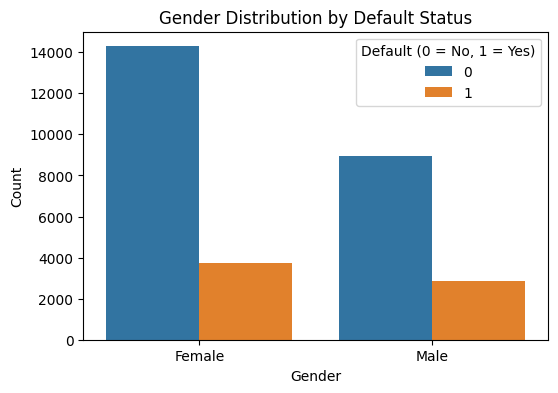

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x="sex", hue="default_payment_next_month", data=df)

plt.title("Gender Distribution by Default Status")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Default (0 = No, 1 = Yes)")
plt.show()

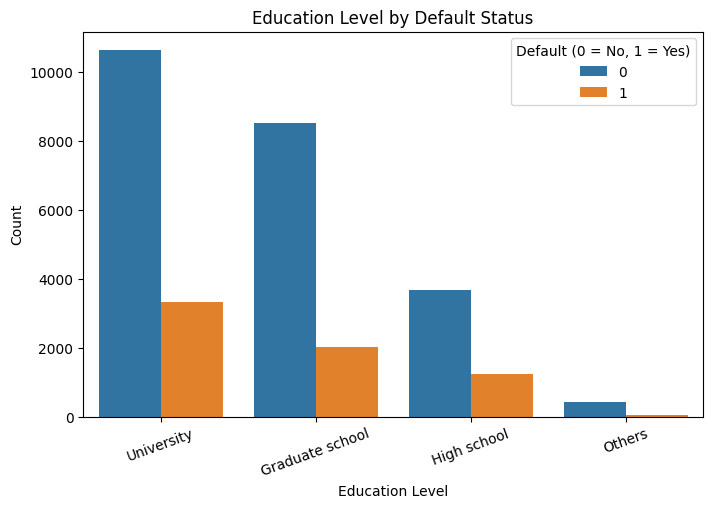

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(x="education", hue="default_payment_next_month", data=df)

plt.title("Education Level by Default Status")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.xticks(rotation=20)
plt.legend(title="Default (0 = No, 1 = Yes)")
plt.show()

In [33]:
pd.crosstab(df["education"], df["default_payment_next_month"], normalize="index")

default_payment_next_month,0,1
education,,
Graduate school,0.808200,0.191800
High school,0.748874,0.251126
Others,0.929336,0.070664
University,0.762321,0.237679


The analysis of gender and education level shows relatively modest differences in default behavior across demographic groups. Gender appears to have minimal impact, as both males and females exhibit similar proportions of default and non-default cases, with only slight variation. In contrast, education level shows some differentiation, where individuals with lower education levels, such as high school, exhibit higher default rates compared to those with graduate-level education or other categories. However, these differences are not as pronounced as those observed in financial and behavioral variables. Overall, demographic features provide additional context but are weaker predictors of default risk compared to payment history and financial indicators. 

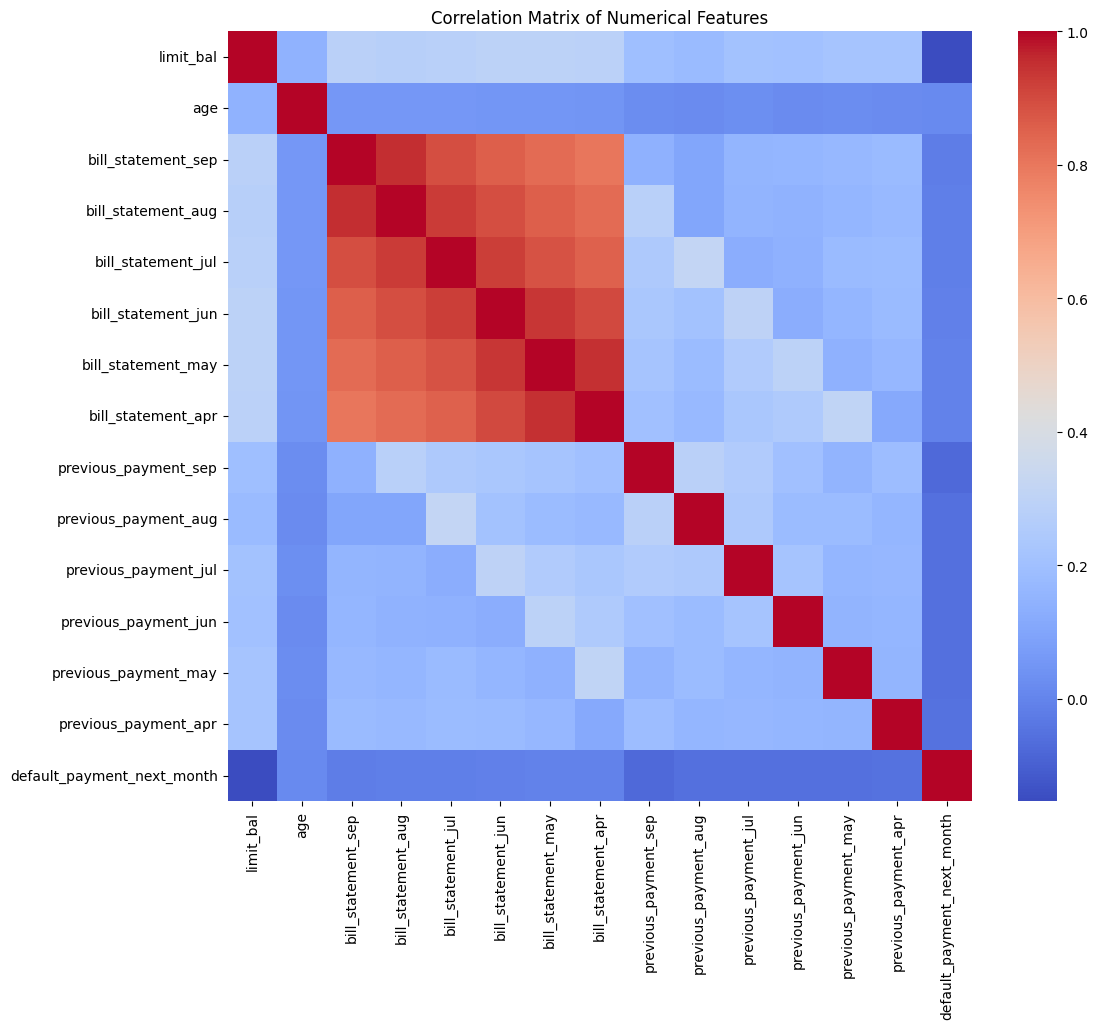

In [35]:
#correlation between features
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

#plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

The correlation matrix shows strong relationships among bill statement variables across different months, indicating consistent customer balance behavior over time. Payment variables also exhibit moderate correlations, suggesting stable repayment patterns. In contrast, demographic features such as age show minimal correlation with other varaibles. Notably, the target variable shows weak linear correlations with most numerical features, indicating that default risk is not driven by a single factor but rather a combination of behavioral and financial patterns. These findings suggest the presence of muliticollinearity among financial variables. 

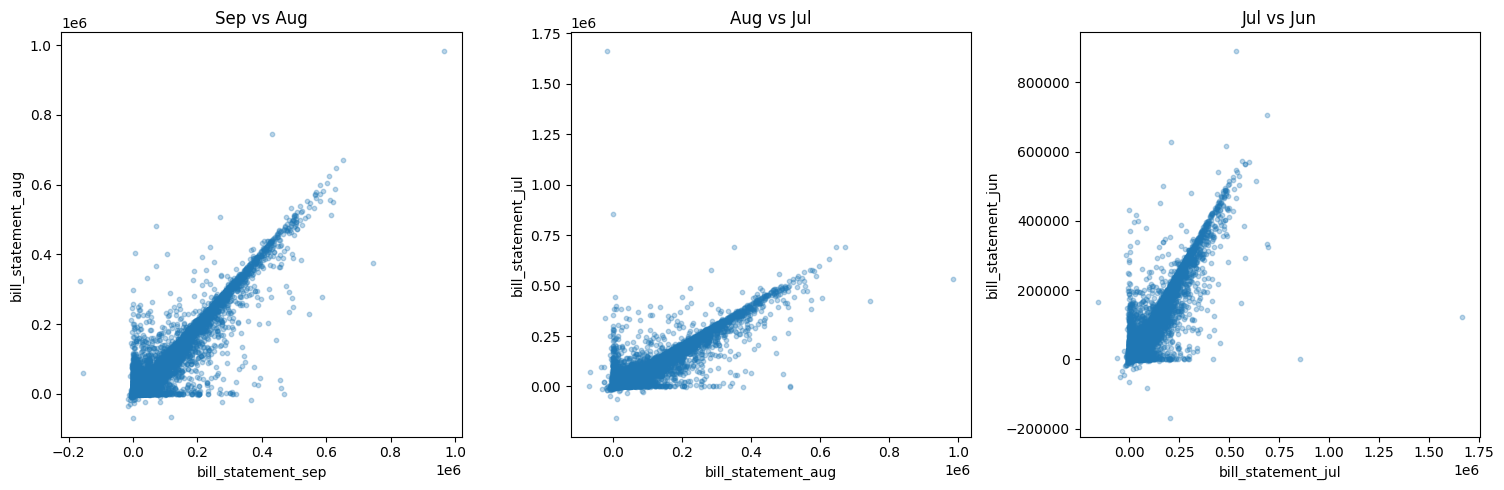

In [ ]:
#scatter plots of highly correlated bill variables
pairs = [
    ("bill_statement_sep", "bill_statement_aug"),
    ("bill_statement_aug", "bill_statement_jul"),
    ("bill_statement_jul", "bill_statement_jun")
]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, (x_col, y_col) in enumerate(pairs):
    axes[i].scatter(
        df[x_col],
        df[y_col],
        alpha=0.3,
        s=10
    )
    
    axes[i].set_title(f"{x_col.split('_')[-1].title()} vs {y_col.split('_')[-1].title()}")
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)

plt.tight_layout()
plt.show()


In [38]:
from scipy.stats import pearsonr

for x_col, y_col in pairs:
    r, p = pearsonr(df[x_col], df[y_col])
    
    print(f"{x_col} vs {y_col}")
    print(f"Correlation (r): {r:.4f}")
    print("-" * 40)

bill_statement_sep vs bill_statement_aug
Correlation (r): 0.9515
----------------------------------------
bill_statement_aug vs bill_statement_jul
Correlation (r): 0.9283
----------------------------------------
bill_statement_jul vs bill_statement_jun
Correlation (r): 0.9240
----------------------------------------


The analysis of bill statement variables across consecutive months reveals very strong positive linear relationships, as confirmed by high Pearson correlation coefficients (r = 0.9515 between September and August, r = 0.9283 between August and July, and r = 0.9240 between July and June). These results indicate that customer bill amounts remain highly consistent over time. The scatter plots further support this finding, showing clear diagonal patterns where higher bill amounts in one month correspond to higher amounts in adjacent months. This strong alignment suggests that these features capture similar underylying financial behavior and may introduce redundancy in the dataset. 